<a href="https://colab.research.google.com/github/Poojarautela03/ABTALKS/blob/main/day_09_semantic_similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# WHY VECTORS ARE NECESSARY:
# Plain text is symbolic, not numeric — a computer has no built-in notion
# that "dog" and "puppy" are related, or that "airplane" is unrelated to both.
# Strings can only be compared for exact equality, not for meaning.
# By converting text into numerical vectors (where each dimension reflects
# word importance/frequency), we place text into a mathematical space where
# distance and angle between vectors can approximate semantic relatedness —
# something raw strings can never support directly.

corpus = [
    # Topic 1: Pets/animals
    "The dog ran happily across the park.",
    "My puppy loves to play fetch every morning.",
    "Cats and dogs are the most common household pets.",
    # Topic 2: Technology
    "The new smartphone has an impressive camera.",
    "Artificial intelligence is transforming the tech industry.",
    "Laptops with faster processors improve productivity.",
    # Topic 3: Travel
    "The airplane landed safely despite the storm.",
    "We booked flights for our vacation to Europe.",
    "The airport was crowded during the holiday season.",
    "Traveling by train offers scenic views of the countryside."
]

topics = ["pets"]*3 + ["tech"]*3 + ["travel"]*4
print(f"Corpus size: {len(corpus)} sentences across 3 topics")

Corpus size: 10 sentences across 3 topics


In [2]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Pairwise cosine similarity between all 10 sentences
similarity_matrix = cosine_similarity(tfidf_matrix)
print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(np.round(similarity_matrix, 2))

TF-IDF matrix shape: (10, 66)
Similarity matrix shape: (10, 10)
[[1.   0.   0.07 0.08 0.08 0.   0.16 0.   0.15 0.07]
 [0.   1.   0.   0.   0.   0.   0.   0.09 0.   0.  ]
 [0.07 0.   1.   0.03 0.03 0.   0.07 0.   0.06 0.03]
 [0.08 0.   0.03 1.   0.04 0.   0.08 0.   0.07 0.03]
 [0.08 0.   0.03 0.04 1.   0.   0.08 0.   0.07 0.03]
 [0.   0.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.16 0.   0.07 0.08 0.08 0.   1.   0.   0.15 0.07]
 [0.   0.09 0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.15 0.   0.06 0.07 0.07 0.   0.15 0.   1.   0.06]
 [0.07 0.   0.03 0.03 0.03 0.   0.07 0.   0.06 1.  ]]


In [4]:
def find_similar(query, corpus, top_k=3):
    corpus_vectors = vectorizer.transform(corpus)
    query_vector = vectorizer.transform([query])

    scores = cosine_similarity(query_vector, corpus_vectors)[0]
    ranked = sorted(zip(scores, corpus), reverse=True, key=lambda x: x[0])

    print(f"Query: '{query}'\n")
    for score, sentence in ranked[:top_k]:
        print(f"  [{score:.4f}] {sentence}")
    return ranked[:top_k]

In [5]:
print("=== Similar concept: 'dog' vs corpus ===")
find_similar("I saw a dog at the park", corpus, top_k=3)

print("\n=== Similar concept: 'puppy' vs corpus ===")
find_similar("A cute puppy was playing outside", corpus, top_k=3)

print("\n=== Dissimilar concept: 'airplane' vs pet sentences ===")
find_similar("The airplane flew over the mountains", corpus, top_k=3)

print("\n=== Cross-check: dog vs airplane directly ===")
dog_vec = vectorizer.transform(["The dog ran in the park"])
plane_vec = vectorizer.transform(["The airplane flew high in the sky"])
score = cosine_similarity(dog_vec, plane_vec)[0][0]
print(f"'dog' vs 'airplane' similarity: {score:.4f}  (expect low — unrelated topics)")

puppy_vec = vectorizer.transform(["A dog is a loyal pet"])
puppy_vec2 = vectorizer.transform(["My puppy is very playful"])
score2 = cosine_similarity(puppy_vec, puppy_vec2)[0][0]
print(f"'dog' vs 'puppy' similarity: {score2:.4f}  (expect higher — related topic)")

=== Similar concept: 'dog' vs corpus ===
Query: 'I saw a dog at the park'

  [0.6783] The dog ran happily across the park.
  [0.1302] The airplane landed safely despite the storm.
  [0.1205] The airport was crowded during the holiday season.

=== Similar concept: 'puppy' vs corpus ===
Query: 'A cute puppy was playing outside'

  [0.2682] The airport was crowded during the holiday season.
  [0.2544] My puppy loves to play fetch every morning.
  [0.0000] The dog ran happily across the park.

=== Dissimilar concept: 'airplane' vs pet sentences ===
Query: 'The airplane flew over the mountains'

  [0.5725] The airplane landed safely despite the storm.
  [0.2790] The dog ran happily across the park.
  [0.2581] The airport was crowded during the holiday season.

=== Cross-check: dog vs airplane directly ===
'dog' vs 'airplane' similarity: 0.3424  (expect low — unrelated topics)
'dog' vs 'puppy' similarity: 0.4082  (expect higher — related topic)


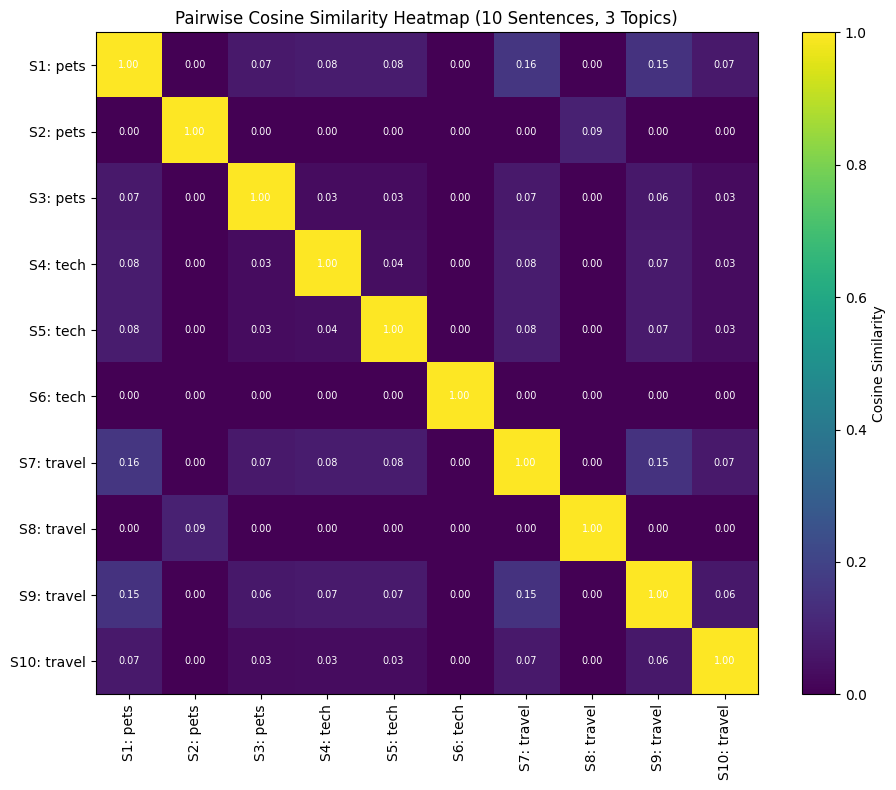

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(similarity_matrix, cmap='viridis')

labels = [f"S{i+1}: {topics[i]}" for i in range(len(corpus))]
ax.set_xticks(range(len(corpus)))
ax.set_yticks(range(len(corpus)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

for i in range(len(corpus)):
    for j in range(len(corpus)):
        ax.text(j, i, f"{similarity_matrix[i,j]:.2f}",
                 ha="center", va="center", color="white", fontsize=7)

ax.set_title("Pairwise Cosine Similarity Heatmap (10 Sentences, 3 Topics)")
plt.colorbar(im, label="Cosine Similarity")
plt.tight_layout()
plt.show()

## Why Cosine Similarity Measures Angle, Not Distance

Cosine similarity computes the cosine of the angle between two vectors:

    cos(θ) = (A · B) / (||A|| × ||B||)

This matters because in TF-IDF space, vector *magnitude* mostly reflects
document length and word repetition, not meaning — a long sentence
repeating "dog" many times would have a much larger vector magnitude
than a short sentence that also happens to be about dogs, even though
both are semantically about the same thing.

Euclidean *distance* is sensitive to this magnitude difference: two
sentences on the same topic but of very different lengths could end up
"far apart" in raw distance terms, even though they point in the same
direction (same topical meaning).

Cosine similarity ignores magnitude entirely and only measures
*direction* — how aligned two vectors are. This makes it far more
robust for text comparison, since it correctly identifies documents as
similar based on their relative word-usage pattern, regardless of how
long or short they are.